Loading data...

--- 1. Headline Length Statistics ---
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


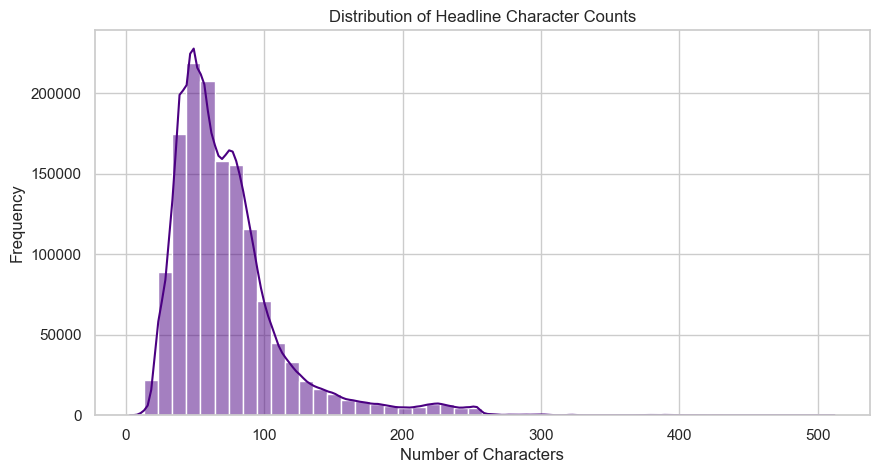


--- 2. Top 10 Publishers ---
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_20488\1616914733.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.index, y=top_publishers.values, palette='viridis')


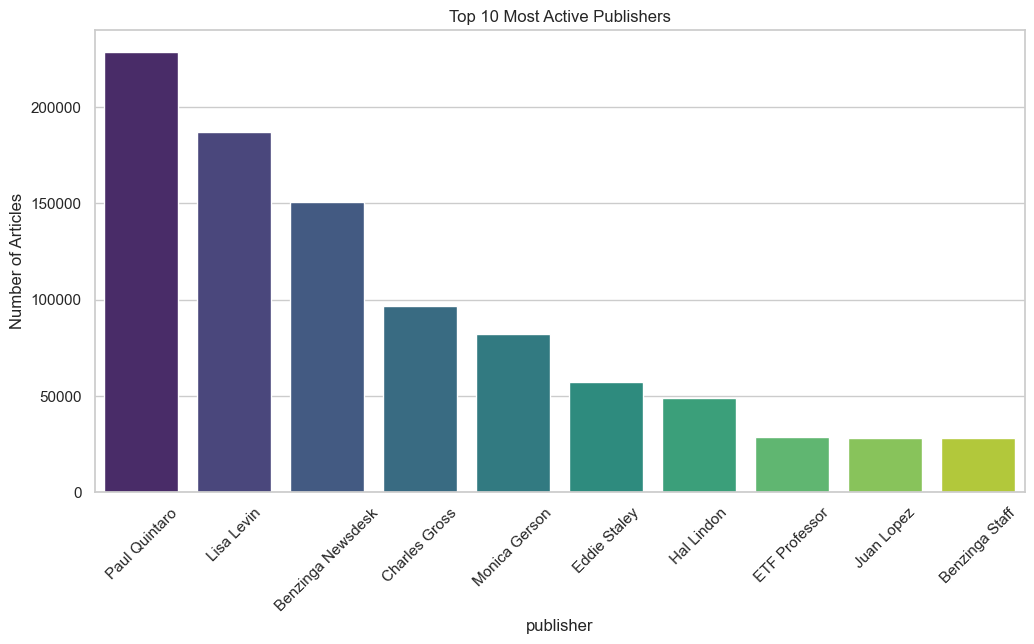


--- 3. Time Series Analysis ---
Parsing dates (this might take a minute)...


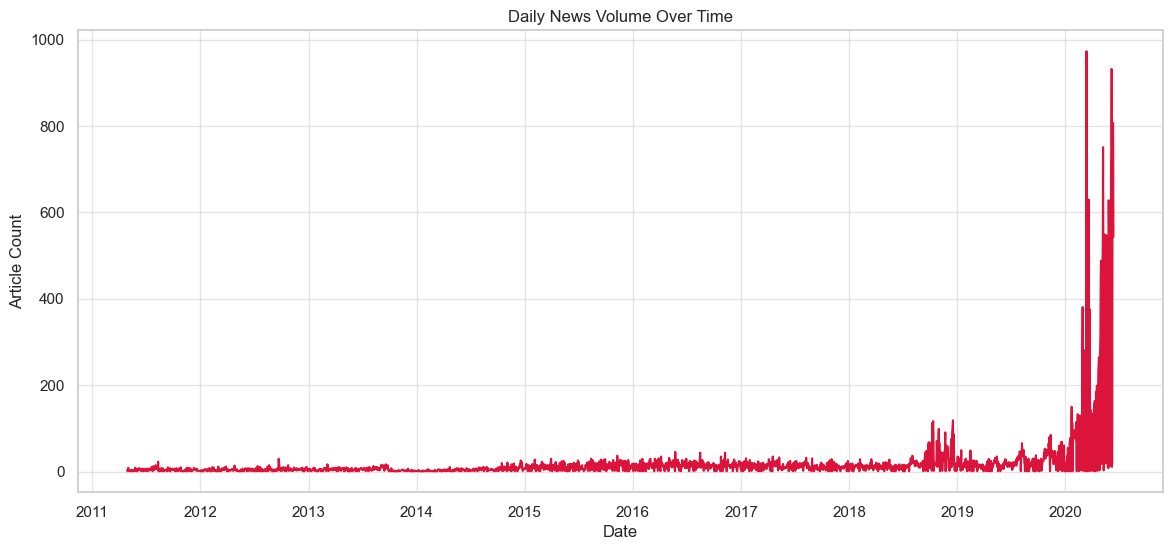

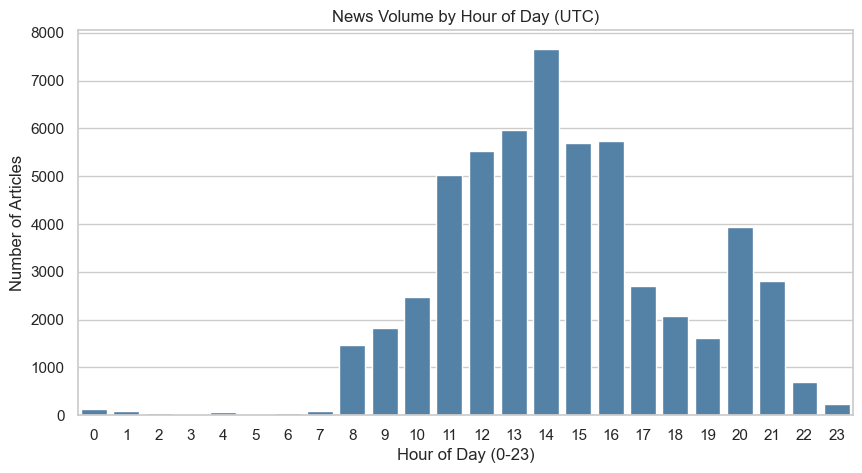


--- 4. Text Analysis (Keywords & Phrases) ---
Analyzing headline text...


C:\Users\HP\AppData\Local\Temp\ipykernel_20488\1616914733.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=word_freq, x='Frequency', y='Keyword/Phrase', palette='magma')


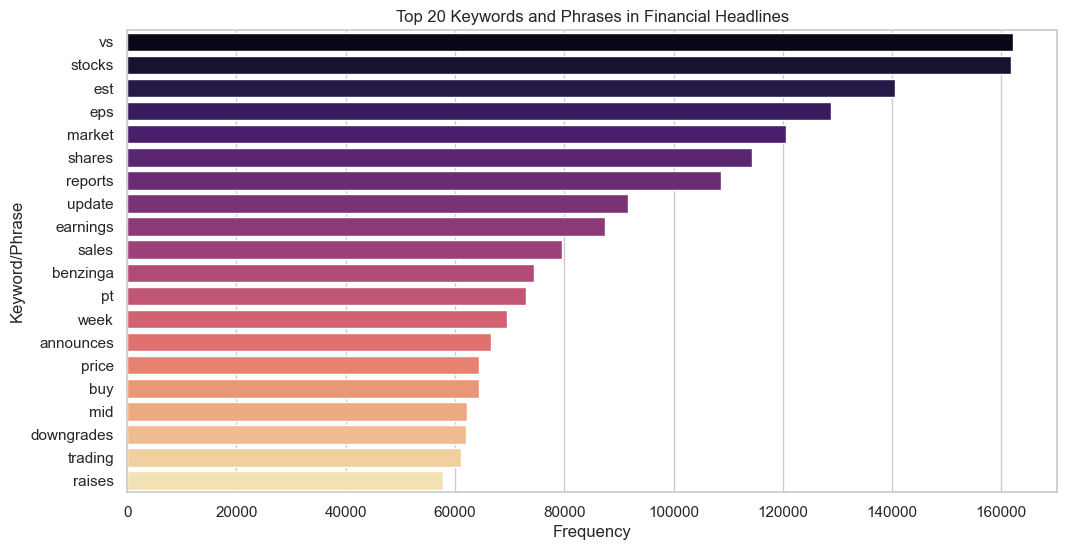

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")

print("Loading data...")
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])


print("\n--- 1. Headline Length Statistics ---")
df['headline_length'] = df['headline'].astype(str).apply(len)
print(df['headline_length'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['headline_length'], bins=50, kde=True, color='indigo')
plt.title('Distribution of Headline Character Counts')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()


print("\n--- 2. Top 10 Publishers ---")
top_publishers = df['publisher'].value_counts().head(10)
print(top_publishers)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers.index, y=top_publishers.values, palette='viridis')
plt.title('Top 10 Most Active Publishers')
plt.xticks(rotation=45)
plt.ylabel('Number of Articles')
plt.show()


print("\n--- 3. Time Series Analysis ---")
print("Parsing dates (this might take a minute)...")
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df_time = df.dropna(subset=['date']).copy()

daily_volume = df_time.groupby(df_time['date'].dt.date).size()

plt.figure(figsize=(14, 6))
daily_volume.plot(color='crimson', linewidth=1.5)
plt.title('Daily News Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Article Count')
plt.grid(True, alpha=0.5)
plt.show()

df_time['hour'] = df_time['date'].dt.hour
hourly_volume = df_time['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_volume.index, y=hourly_volume.values, color='steelblue')
plt.title('News Volume by Hour of Day (UTC)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Articles')
plt.show()


print("\n--- 4. Text Analysis (Keywords & Phrases) ---")
print("Analyzing headline text...")

vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=20)

X = vectorizer.fit_transform(df['headline'].dropna().astype(str))

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
word_freq = pd.DataFrame({'Keyword/Phrase': words, 'Frequency': counts})
word_freq = word_freq.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=word_freq, x='Frequency', y='Keyword/Phrase', palette='magma')
plt.title('Top 20 Keywords and Phrases in Financial Headlines')
plt.show()

 PART 1: RECURRING PHRASES (TF-IDF)


C:\Users\HP\AppData\Local\Temp\ipykernel_20488\3743159525.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=phrase_df, x='TF-IDF Score', y='Phrase', palette='crest')


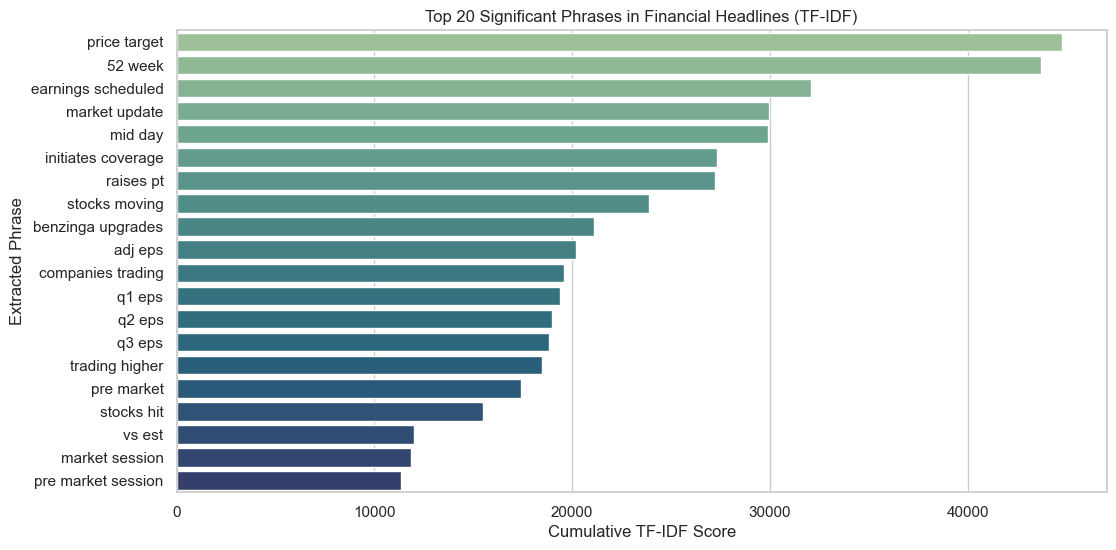


 PART 2: TOPIC MODELING (LDA)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_theme(style="whitegrid")

df_text = df.dropna(subset=['headline']).copy()
headlines = df_text['headline'].astype(str)

print("="*50)
print(" PART 1: RECURRING PHRASES (TF-IDF)")
print("="*50)

tfidf_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(2, 3), max_features=20)
tfidf_matrix = tfidf_vectorizer.fit_transform(headlines)

phrases = tfidf_vectorizer.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1
phrase_df = pd.DataFrame({'Phrase': phrases, 'TF-IDF Score': scores}).sort_values(by='TF-IDF Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=phrase_df, x='TF-IDF Score', y='Phrase', palette='crest')
plt.title('Top 20 Significant Phrases in Financial Headlines (TF-IDF)')
plt.xlabel('Cumulative TF-IDF Score')
plt.ylabel('Extracted Phrase')
plt.show()

print("\n" + "="*50)
print(" PART 2: TOPIC MODELING (LDA)")
print("="*50)

lda_vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=5, max_features=1000)
lda_matrix = lda_vectorizer.fit_transform(headlines)

num_topics = 5
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(lda_matrix)

words = lda_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    top_words_indices = topic.argsort()[:-11:-1]
    top_words = [words[i] for i in top_words_indices]
    print(f"📌 Topic {topic_idx + 1}:")
    print(" | ".join(top_words))
    print("-" * 50)